# Term Project

Student Name: Sonia Siddiqui 

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

sns.set(style="whitegrid", context="notebook")

# New York Loans Dataset

## Define a Project 

For my term project, I have chosen a data set showing loans taken out for mortgage payements. 

This is a large dataset, so I will clean it up below.  

Below I will answer questions from the "Define a Project" section of the project instructions pdf.

1. Describe well the new model that you are using: Group similar loans or borrowers without using labels. This works well because I am looking to explore patterns among borrowers and loan segments. From what I have seen online, tt works well with mixed numeric features after normalization, I don’t need target labels, and it helps discover hidden segments in  my data (like types of borrowers or loan structures).

2. What is your data set about?: My dataset is financial and geographic information on SONYMA Loans purchased since 2004 in New York. The data is provided by New York State Homes & Community Renewal. Here is the link to the website: https://data.ny.gov/Economic-Development/State-of-New-York-Mortgage-Agency-SONYMA-Loans-Pur/22ew-dxez/about_data

4. What is exactly your research question?: Do certain counties show distinct patterns in loan characteristics?
4.2 What do you want to learn from data?: I expect to learn more about the loan purchase patterns in different counties.
4.3 What is your learning model ,e.g., a Classification, Clustering, etc?: I am using clustering. Specifically, I have chosen the Data Clustering with Gaussian Mixture Models.

5. What is your current expectations about the results? Why?: I expect to find three clusters. Cluster 1: Small loans for detached homes in upstate NY. Cluster 2: Large loans for condos/cooperatives in NYC. Cluster 3: Medium loans for multi-unit properties. This is my guess because I think loan characteristics should vary by location.

6. Describe how you evaluate your project?: Use Silhouette Score or Bayesian Information Criterion (BIC) to evaluate the optimal number of clusters.
6.2 How to access the correctness of your model?: Interpret clusters and look at average loan amount, county distribution, or property type per cluster.
6.3 How well would you expect that the model will work?: Depending on the model, I am not sure how well it will work. I am excited to find out! 


In [25]:
loans_df = pd.read_csv("NY_Loans_Purchased.csv")
loans_df

,Bond Series,Original Loan Amount,Loan Purchase Date,Purchase Year,Original Loan To Value,Loan Type,SONYMA DPAL/CCAL Amount,Original Term,County,FIPS Code,Number of Units,Property Type,Housing Type,Household Size
0,HMB Warehouse,"$117,370",06/30/2016,2016,97%,Conventional,"$3,630",360,Schuyler,36097,1 Family,Detached,Existing,1
1,HMB Warehouse,"$83,000",06/30/2016,2016,89%,Conventional,"$3,000",360,Chautauqua,36013,1 Family,Detached,Existing,1
2,HMB Warehouse,"$133,860",06/30/2016,2016,97%,Conventional,$0,360,Livingston,36051,1 Family,Detached,Existing,2
3,HMB Warehouse,"$127,300",06/30/2016,2016,95%,Conventional,$0,360,Erie,36029,1 Family,Detached,Existing,1
4,HMB Warehouse,"$74,150",06/30/2016,2016,78%,Conventional,$0,360,Rensselaer,36083,1 Family,Detached,Existing,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28523,Series 109/110,"$33,250",01/02/2004,2004,95%,Conventional,"$4,549",360,Oswego,36075,1 Family,Detached,Existing,1
28524,Series 109/110,"$101,000",01/02/2004,2004,96.19%,Conventional,NaN,360,Rensselaer,36083,2 Family,Detached,Existing,1
28525,Series 109/110,"$80,000",01/02/2004,2004,96.5%,Conventional,"$4,218",360,Erie,36029,2 Family,Detached,Existing,1
28526,Series 109/110,"$52,300",01/02/2004,2004,96.85%,Conventional,"$4,383",360,Monroe,36055,1 Family,Detached,Existing,1


# Part 1: Cleaning 





In [ ]:
def parse_currency_column(s):
    """Parse currency string like '$117,370.00' or '$3,630.00' to float. Returns NaN if cannot parse."""
    if pd.isna(s):
        return np.nan
    try:
        # remove $ and commas
        return float(str(s).replace('$','').replace(',','').strip())
    except:
        return np.nan

def parse_percent_column(s):
    """Parse percent strings like '97%' or '97.0%' or numeric strings."""
    if pd.isna(s):
        return np.nan
    try:
        ss = str(s).strip().replace('%','')
        return float(ss)/100.0
    except:
        try:
            return float(s)
        except:
            return np.nan

# We'll attempt to find likely columns and convert them automatically:
loans_df_clean = loans_df.copy()

# Clean up column names
loans_df_clean.columns = loans_df_clean.columns.str.strip()

# Map common name patterns -> conversions
for col in loans_df_clean.columns:
    lc = col.lower()
    # Currency detection by example values (if dtype object & contains '$')
    sample = loans_df_clean[col].dropna().astype(str).head(10).tolist()
    if any('$' in s for s in sample):
        print("Parsing currency column:", col)
        loans_df_clean[col] = loans_df_clean[col].map(parse_currency_column)
    # Percent detection
    elif any('%' in s for s in sample):
        print("Parsing percent column:", col)
        loans_df_clean[col] = loans_df_clean[col].map(parse_percent_column)
    # Year or date columns: try to convert Purchase Date-like columns to datetime
    if 'date' in lc or 'purchase' in lc or 'year' in lc:
        # attempt datetime conversion
        try:
            loans_df_clean[col] = pd.to_datetime(loans_df_clean[col], errors='coerce')
            if loans_df_clean[col].notnull().sum() > 0:
                print("Parsed datetime column:", col)
        except:
            pass

# Show types after attempted conversions
display(loans_df_clean.dtypes)

Parsing currency column: Original Loan Amount
Parsed datetime column: Loan Purchase Date
Parsed datetime column: Purchase Year
Parsing percent column: Original Loan To Value
Parsing currency column: SONYMA DPAL/CCAL Amount


Bond Series                        object
Original Loan Amount              float64
Loan Purchase Date         datetime64[ns]
Purchase Year              datetime64[ns]
Original Loan To Value            float64
Loan Type                          object
SONYMA DPAL/CCAL Amount           float64
Original Term                       int64
County                             object
FIPS Code                           int64
Number of Units                    object
Property Type                      object
Housing Type                       object
Household Size                      int64
dtype: object

In [ ]:
# Ensure all column names are stripped in lists
possible_num = [c.strip() for c in [
    'Original Loan Amount', 'Loan Type', 'Loan Purchase Date', 'Original Loan To Value', 
    'Original Term', 'Purchase Year', 'FIPS Code', 'Household Size',
    'SONYMA DPAL/CCAL Amount', 'Number of Units', 'Original Term'
]]

possible_cat = [c.strip() for c in [
    'Loan Type', 'Property Type', 'Housing Type', 'County'
]]

num_cols = [c for c in possible_num if c in loans_df_clean.columns]
cat_cols = [c for c in possible_cat if c in loans_df_clean.columns]

print("Numeric columns used:", num_cols)
print("Categorical columns used:", cat_cols)

Numeric columns used: ['Original Loan Amount', 'Loan Type', 'Loan Purchase Date', 'Original Loan To Value', 'Original Term', 'Purchase Year', 'FIPS Code', 'Household Size', 'SONYMA DPAL/CCAL Amount', 'Number of Units', 'Original Term']
Categorical columns used: ['Loan Type', 'Property Type', 'Housing Type', 'County']


# Part 2: Select Features for Clustering
Choose meaningful numeric + categorical features that describe a loan.

In [33]:
# 1. Clean up any trailing spaces
loans_df_clean.columns = loans_df_clean.columns.str.strip()

# 2. Identify numeric, categorical, and datetime columns dynamically
num_cols = loans_df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = loans_df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. Convert datetime to numeric (ordinal form)
for col in loans_df_clean.select_dtypes(include=['datetime64']).columns:
    loans_df_clean[col] = loans_df_clean[col].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
    num_cols.append(col)

print("Numeric columns used:", num_cols)
print("Categorical columns used:", cat_cols)

# 4. Drop rows missing all numeric data
df_subset = loans_df_clean[num_cols + cat_cols].copy()
df_subset = df_subset.dropna(subset=num_cols, how='all')
print("After dropna subset shape:", df_subset.shape)

Numeric columns used: ['Original Loan Amount', 'Original Loan To Value', 'SONYMA DPAL/CCAL Amount', 'Original Term', 'FIPS Code', 'Household Size', 'Loan Purchase Date', 'Purchase Year']
Categorical columns used: ['Bond Series', 'Loan Type', 'County', 'Number of Units', 'Property Type', 'Housing Type']
After dropna subset shape: (28528, 14)


# Part 3: Preprocessing pipeline: impute numeric, encode categoricals, scale

In [35]:
# Identify column types
num_cols = df_subset.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_subset.select_dtypes(include=['object', 'category']).columns

# Check what columns are being used
print("Numeric columns:", num_cols.tolist())
print("Categorical columns:", cat_cols.tolist())

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])
# Fit-transform to create matrix for clustering
X = preprocessor.fit_transform(df_subset)
print("Feature matrix shape after preprocessing:", X.shape)


Numeric columns: ['Original Loan Amount', 'Original Loan To Value', 'SONYMA DPAL/CCAL Amount', 'Original Term', 'FIPS Code', 'Household Size', 'Loan Purchase Date', 'Purchase Year']
Categorical columns: ['Bond Series', 'Loan Type', 'County', 'Number of Units', 'Property Type', 'Housing Type']
Feature matrix shape after preprocessing: (28528, 213)


# Part 4: Dim reduction for vizualization (pca)


In [36]:
pca = PCA(n_components=0.95, random_state=42)   # keep 95% variance
X_pca = pca.fit_transform(X)
print("PCA reduced shape:", X_pca.shape)
explained = pca.explained_variance_ratio_.sum()
print(f"PCA retained variance: {explained:.3f}")

PCA reduced shape: (28528, 51)
PCA retained variance: 0.951


# Part 6: Find optimal number of GMM components using BIC & silhouette

Warning: this part takes a while to run. 



Searching best number of components for GMM...
n=2: BIC=-31811813.3, AIC=-32191785.1, silhouette=0.1411
n=3: BIC=-40154395.4, AIC=-40724357.3, silhouette=0.1030
n=4: BIC=-43469137.5, AIC=-44229089.4, silhouette=0.1001
n=5: BIC=-44891943.5, AIC=-45841885.5, silhouette=0.0584
n=6: BIC=-45788957.6, AIC=-46928889.6, silhouette=0.1057
n=7: BIC=-47392922.3, AIC=-48722844.3, silhouette=0.0841
n=8: BIC=-48614843.9, AIC=-50134756.0, silhouette=0.0168
n=9: BIC=-49007832.0, AIC=-50717734.1, silhouette=0.0275
n=10: BIC=-49827902.1, AIC=-51727794.2, silhouette=0.0197


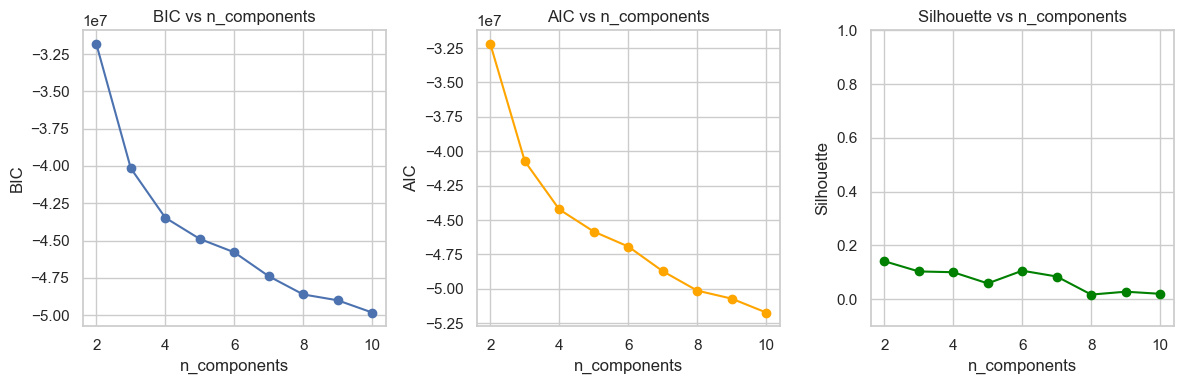

Best by BIC: 10; Best by silhouette: 2


In [ ]:
n_components_range = range(2, 11)   # try 2..10 clusters
bic_scores = []
aic_scores = []
sil_scores = []
gmm_models = {}

print("\nSearching best number of components for GMM...")
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42, n_init=5)
    gmm.fit(X)
    labels = gmm.predict(X)
    bic = gmm.bic(X)
    aic = gmm.aic(X)
    # silhouette requires at least 2 labels and less than n_samples clusters
    try:
        sil = silhouette_score(X, labels)
    except:
        sil = np.nan
    bic_scores.append(bic)
    aic_scores.append(aic)
    sil_scores.append(sil)
    gmm_models[n] = gmm
    print(f"n={n}: BIC={bic:.1f}, AIC={aic:.1f}, silhouette={sil:.4f}")

# Plot BIC/AIC and silhouette
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(list(n_components_range), bic_scores, marker='o')
plt.title("BIC vs n_components")
plt.xlabel("n_components")
plt.ylabel("BIC")

plt.subplot(1,3,2)
plt.plot(list(n_components_range), aic_scores, marker='o', color='orange')
plt.title("AIC vs n_components")
plt.xlabel("n_components")
plt.ylabel("AIC")

plt.subplot(1,3,3)
plt.plot(list(n_components_range), sil_scores, marker='o', color='green')
plt.title("Silhouette vs n_components")
plt.xlabel("n_components")
plt.ylabel("Silhouette")
plt.ylim(-0.1, 1)
plt.tight_layout()
plt.show()

# Choose best number of clusters: pick n with lowest BIC, but also consider silhouette.
best_n_bic = n_components_range[np.argmin(bic_scores)]
best_n_sil = n_components_range[np.nanargmax(sil_scores)]
print(f"Best by BIC: {best_n_bic}; Best by silhouette: {best_n_sil}")

# We'll pick the BIC-optimal one (you can change to best_n_sil)
chosen_n = best_n_bic
gmm_best = gmm_models[chosen_n]
labels = gmm_best.predict(X)
df_subset = df_subset.reset_index(drop=True)
df_subset['cluster'] = labels


# Part 7: Cluster Summary and Interpretation

In [38]:
print("\nCluster counts:")
print(df_subset['cluster'].value_counts().sort_index())

# For each cluster compute numeric means and categorical mode
cluster_summary_num = df_subset.groupby('cluster')[num_cols].mean().T
display(cluster_summary_num)

if len(cat_cols) > 0:
    cluster_summary_cat = {}
    for c in cat_cols:
        cluster_summary_cat[c] = df_subset.groupby('cluster')[c].agg(lambda x: x.mode().iat[0] if len(x.mode())>0 else np.nan)
    cluster_summary_cat = pd.DataFrame(cluster_summary_cat)
    display(cluster_summary_cat)

# Show some example rows from each cluster
for k in sorted(df_subset['cluster'].unique()):
    print(f"\nExamples from cluster {k} (first 5 rows):")
    display(df_subset[df_subset['cluster']==k].head(5))


Cluster counts:
cluster
0    1219
1    3625
2    5898
3    2720
4    1154
5    5410
6     785
7     830
8    5703
9    1184
Name: count, dtype: int64


cluster,0,1,2,3,4,5,6,7,8,9
Original Loan Amount,134367.670221,97647.085793,201855.844015,194638.437868,72790.211438,100945.247874,227239.191083,129111.763855,99482.818867,103057.194257
Original Loan To Value,0.899768,0.903463,0.799150,0.811865,0.909724,0.901279,0.847439,0.812884,0.901502,0.903928
SONYMA DPAL/CCAL Amount,2924.082811,4832.778944,6218.042162,8008.914271,4295.795389,5090.480345,9664.040094,5144.874429,5130.501167,2541.287193
Original Term,360.000000,362.002759,360.000000,360.000000,357.452340,361.375231,480.000000,364.771084,360.000000,360.000000
FIPS Code,36048.696473,36027.080000,36077.491353,36093.771324,36024.230503,36085.174861,36080.844586,36053.718072,36044.219008,36053.555743
Household Size,1.767842,1.708690,2.069176,1.806250,1.909012,1.822921,2.411465,1.821687,1.606698,1.724662
Loan Purchase Date,735053.557834,732677.275034,734844.773143,732548.594853,732514.964471,732527.816636,733773.982166,734075.425301,732494.649483,735451.186655
Purchase Year,719163.000000,719163.000000,719163.000000,719163.000000,719163.000000,719163.000000,719163.000000,719163.000000,719163.000000,719163.000000


,Bond Series,Loan Type,County,Number of Units,Property Type,Housing Type
cluster,,,,,,
0,Series 38A/39/40,Conventional,Monroe,1 Family,Detached,Existing
1,Series 127/128/129,Conventional,Monroe,1 Family,Detached,Existing
2,Series 38D/46/47,Conventional,Suffolk,1 Family,Detached,Existing
3,Series 109/110,Conventional,Suffolk,1 Family,Detached,Existing
4,Series 116,Conventional,Chemung,1 Family,Detached,Existing
5,Series 113/114/115,Conventional,Onondaga,1 Family,Detached,Existing
6,Series 38D/46/47,Conventional,Suffolk,1 Family,Detached,Existing
7,Series 160/161/162,Conventional,Kings,1 Family,Detached,Existing
8,Series 111/112,Conventional,Monroe,1 Family,Detached,Existing



Examples from cluster 0 (first 5 rows):


,Original Loan Amount,Original Loan To Value,SONYMA DPAL/CCAL Amount,Original Term,FIPS Code,Household Size,Loan Purchase Date,Purchase Year,Bond Series,Loan Type,County,Number of Units,Property Type,Housing Type,cluster
239,174500.0,0.9700,5235.0,360,36055,1,736096,719163,Series 195/196,Conventional,Monroe,1 Family,Detached,Existing,0
240,113850.0,0.9000,0.0,360,36029,1,736096,719163,Series 195/196,Conventional,Erie,2 Family,Detached,Existing,0
241,102800.0,0.9700,0.0,360,36055,1,736096,719163,Series 195/196,Conventional,Monroe,1 Family,Detached,Existing,0
242,97600.0,0.8000,0.0,360,36055,1,736096,719163,Series 195/196,Conventional,Monroe,1 Family,Detached,Existing,0
243,141000.0,0.9495,0.0,360,36029,1,736096,719163,Series 195/196,Conventional,Erie,1 Family,Detached,Existing,0


...

,Original Loan Amount,Original Loan To Value,SONYMA DPAL/CCAL Amount,Original Term,FIPS Code,Household Size,Loan Purchase Date,Purchase Year,Bond Series,Loan Type,County,Number of Units,Property Type,Housing Type,cluster
181,46957.0,0.9700,3000.0,360,36043,4,736110,719163,HMB Warehouse,Conventional,Herkimer,1 Family,Detached,Existing,7
3040,65800.0,0.2531,7800.0,360,36103,3,735312,719163,R_HMB 42_43,Conventional,Suffolk,1 Family,Detached,Existing,7
3046,194000.0,0.7760,7500.0,360,36103,1,735312,719163,R_HMB 160_161_162,Conventional,Suffolk,1 Family,Condominium,New,7
3047,144000.0,0.9616,4492.0,360,36071,4,735312,719163,R_HMB _Series 148-150,Conventional,Orange,1 Family,Detached,Existing,7
3048,338000.0,0.7953,12750.0,360,36005,2,735312,719163,R_HMB 120_121_122,Conventional,Bronx,3 Family,Attached,Existing,7



Examples from cluster 8 (first 5 rows):


,Original Loan Amount,Original Loan To Value,SONYMA DPAL/CCAL Amount,Original Term,FIPS Code,Household Size,Loan Purchase Date,Purchase Year,Bond Series,Loan Type,County,Number of Units,Property Type,Housing Type,cluster
262,94905.0,0.9500,0.0,360,36105,1,736096,719163,HMB Warehouse,Conventional,Sullivan,1 Family,Detached,Existing,8
605,111550.0,0.9700,3346.0,360,36105,1,736040,719163,Series 195/196,Conventional,Sullivan,1 Family,Detached,Existing,8
2982,129600.0,0.9600,4050.0,360,36105,3,735340,719163,Series 181/182/183/184,Conventional,Sullivan,1 Family,Detached,Existing,8
3049,268000.0,0.8000,10000.0,360,36103,2,735312,719163,R_HMB 163_164,Conventional,Suffolk,1 Family,Condominium,Rehabilitation,8
3057,279850.0,0.9486,NaN,360,36081,2,735312,719163,R_HMB 163_164,Conventional,Queens,1 Family,Attached,Existing,8



Examples from cluster 9 (first 5 rows):


,Original Loan Amount,Original Loan To Value,SONYMA DPAL/CCAL Amount,Original Term,FIPS Code,Household Size,Loan Purchase Date,Purchase Year,Bond Series,Loan Type,County,Number of Units,Property Type,Housing Type,cluster
0,117370.0,0.97,3630.0,360,36097,1,736145,719163,HMB Warehouse,Conventional,Schuyler,1 Family,Detached,Existing,9
1,83000.0,0.89,3000.0,360,36013,1,736145,719163,HMB Warehouse,Conventional,Chautauqua,1 Family,Detached,Existing,9
2,133860.0,0.97,0.0,360,36051,2,736145,719163,HMB Warehouse,Conventional,Livingston,1 Family,Detached,Existing,9
3,127300.0,0.95,0.0,360,36029,1,736145,719163,HMB Warehouse,Conventional,Erie,1 Family,Detached,Existing,9
4,74150.0,0.78,0.0,360,36083,3,736145,719163,HMB Warehouse,Conventional,Rensselaer,1 Family,Detached,Existing,9


# Part 8: Visualize clusters in 2D using PCA (first two components) and t-SNE


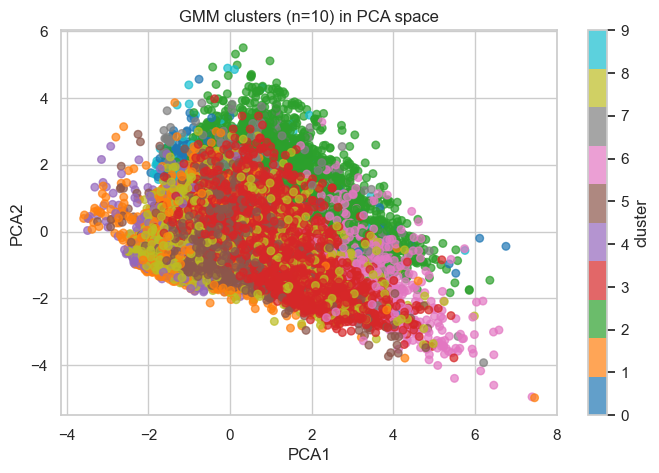

In [39]:
plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', s=30, alpha=0.7)
plt.title(f"GMM clusters (n={chosen_n}) in PCA space")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.colorbar(label='cluster')
plt.show()

# Part 9: Save cluster labels back to original DataFrame and export


In [40]:
df_with_clusters = loans_df.copy()
# align indices if subset removed rows; here we kept indices after reset in df_subset, so map back by index

output_path = "sonyma_clusters_summary.csv"
df_subset.to_csv(output_path, index=False)
print("Wrote cluster summary to:", output_path)

Wrote cluster summary to: sonyma_clusters_summary.csv


# Part 10: Evaluation & Notes for Report, Basic suggestions to improve


In [43]:
print("\nNotes:")
print(f"- GMM chosen with {chosen_n} components (BIC-optimal).")
print(f"- Silhouette score for chosen model: {silhouette_score(X, labels):.4f}")
print("- Interpret clusters by reviewing cluster_summary_num and cluster_summary_cat above.")
print("- Visualize clusters using PCA and t-SNE plots to inspect separation.")

improvement_suggestions = [
    "Create LTV bins, log-transform highly skewed features (loan amount), extract year/month from dates.",
    "Try other clustering methods (Birch, MeanShift, Spectral Clustering, GMM with different covariance types).",
    "Create new features (e.g., loan-to-income ratio if income available, or urban/rural binary from county).",
]
for s in improvement_suggestions:
    print("-", s)


Notes:
- GMM chosen with 10 components (BIC-optimal).
- Silhouette score for chosen model: 0.0197
- Interpret clusters by reviewing cluster_summary_num and cluster_summary_cat above.
- Visualize clusters using PCA and t-SNE plots to inspect separation.
- Create LTV bins, log-transform highly skewed features (loan amount), extract year/month from dates.
- Try other clustering methods (Birch, MeanShift, Spectral Clustering, GMM with different covariance types).
- Create new features (e.g., loan-to-income ratio if income available, or urban/rural binary from county).


# Part 11: References


In [44]:
refs = [
    "Scikit-learn documentation: GaussianMixture — https://scikit-learn.org/stable/modules/mixture.html",
    "t-SNE and Visualization: van der Maaten & Hinton, 2008",
    "Feature engineering best practices: Various blog posts and hands-on guides (Kaggle, Medium)",
    "Imbalanced datasets techniques: SMOTE, class weighting — scikit-learn-contrib imbalanced-learn"
]
print("\nReferences:")
for r in refs:
    print("-", r)


References:
- Scikit-learn documentation: GaussianMixture — https://scikit-learn.org/stable/modules/mixture.html
- t-SNE and Visualization: van der Maaten & Hinton, 2008
- Feature engineering best practices: Various blog posts and hands-on guides (Kaggle, Medium)
- Imbalanced datasets techniques: SMOTE, class weighting — scikit-learn-contrib imbalanced-learn
